# Processing Sequences Using RNNs and CNNs

### Forecasting a Time Series

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
path = Path(r"datasets\CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)
df = df.drop_duplicates()


In [ ]:
df.head(10) # W for Weekdays, A for Saturdays, and U for Sundays or holidays.

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
2001-01-06,A,577401,255356
2001-01-07,U,375831,169825
2001-01-08,W,985221,590706
2001-01-09,W,978377,599905


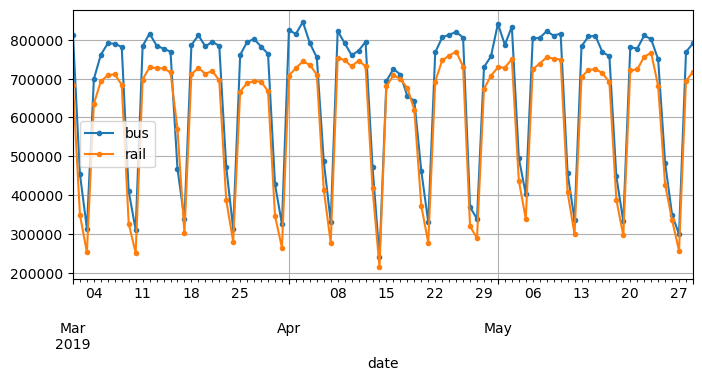

In [8]:
import matplotlib.pyplot as plt

df["2019-03-01":"2019-05-29"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.legend()
plt.show()

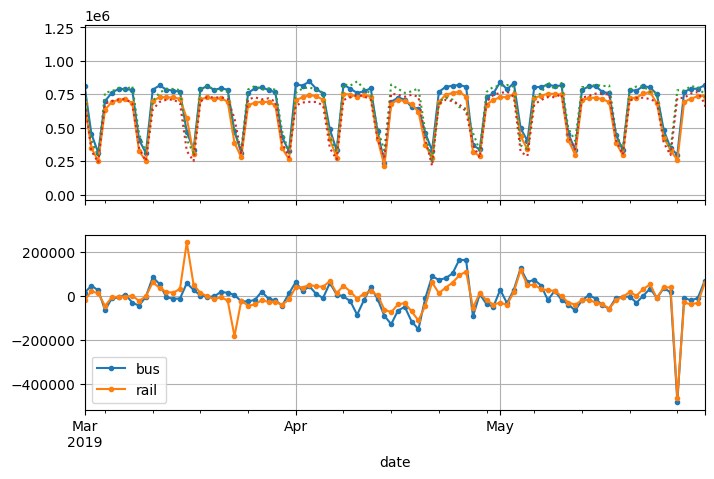

In [11]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
plt.legend()
plt.show()

In [12]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

In [13]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

In [14]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7/targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64